<a href="https://colab.research.google.com/github/Calebchike/EIA-Web-Scrapping/blob/main/EIA_data_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Module**

In [29]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Scrap Data from EIA webpage**


In [31]:
url = "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RWTC&f=W"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
html = response.text

soup = BeautifulSoup(html, "html.parser")

# Get every table on the page.
tables = soup.find_all("table")
print(f"Found {len(tables)} tables on the page.")

# Get all entry which holds the price data print how many rows each table has.
for i, table in enumerate(tables):
    rows = table.find_all("tr")
    print(f"Table {i}: {len(rows)} rows")

Found 8 tables on the page.
Table 0: 12 rows
Table 1: 3 rows
Table 2: 2 rows
Table 3: 1 rows
Table 4: 532 rows
Table 5: 528 rows
Table 6: 2 rows
Table 7: 2 rows


Parse the page. Pull out the table. Turn it into a list of rows.
Run this after step 1 works and you've looked at raw_page.html.

In [44]:
TABLE_INDEX = 5

data_table = tables[TABLE_INDEX]
rows = data_table.find_all("tr")

# pull out the text in every cell, strip blank space off the edges.
records = []
for row in rows:
    cells = row.find_all(["td", "th"])
    cell_text = [c.get_text(strip=True) for c in cells]
    if cell_text:  # skip empty rows
        records.append(cell_text)

print("First 5 rows pulled from the table:")
for r in records[:5]:
    print(r)
print()

# Use pandas to turn the record list into a proper table.
df = pd.DataFrame(records)
print(f"Dataframe shape: {df.shape}")
df.head(5)

First 5 rows pulled from the table:
['Year-Month', 'Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5']
['End Date', 'Value', 'End Date', 'Value', 'End Date', 'Value', 'End Date', 'Value', 'End Date', 'Value']
['1986-Jan', '01/03', '25.78', '01/10', '25.99', '01/17', '24.57', '01/24', '20.31', '01/31', '19.69']
['1986-Feb', '02/07', '16.72', '02/14', '16.25', '02/21', '14.39', '02/28', '14.25', '', '']
['1986-Mar', '03/07', '12.27', '03/14', '13.07', '03/21', '13.45', '03/28', '12.00', '', '']

Dataframe shape: (528, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,Year-Month,Week 1,Week 2,Week 3,Week 4,Week 5,None,None,None,None,None
1,End Date,Value,End Date,Value,End Date,Value,End Date,Value,End Date,Value,None
2,1986-Jan,01/03,25.78,01/10,25.99,01/17,24.57,01/24,20.31,01/31,19.69
3,1986-Feb,02/07,16.72,02/14,16.25,02/21,14.39,02/28,14.25,,
4,1986-Mar,03/07,12.27,03/14,13.07,03/21,13.45,03/28,12.00,,


# **Data Cleaning**

In [45]:
# Clean and reshape DataFrame: drop columns, rename, drop rows, set index
df.drop(columns=[1, 3, 5, 7, 9], inplace=True)
df.columns = ["Year_Month", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5"]
df = df.drop([0, 1])
df.set_index('Year_Month', inplace=True)
df.head()

,Week 1,Week 2,Week 3,Week 4,Week 5
Year_Month,,,,,
1986-Jan,25.78,25.99,24.57,20.31,19.69
1986-Feb,16.72,16.25,14.39,14.25,
1986-Mar,12.27,13.07,13.45,12.00,
1986-Apr,11.44,13.46,12.16,13.44,
1986-May,13.76,15.08,15.74,16.37,14.64


## **Melt Data**

In [49]:
# Reset Year_Month from index back into a column
df_long = df.reset_index().melt(
    id_vars="Year_Month",
    value_vars=["Week 1", "Week 2", "Week 3", "Week 4", "Week 5"],
    var_name="Week",
    value_name="Price"
)

# Drop rows where Price is blank - not every month has a Week 5
df_long = df_long.dropna(subset=["Price"])

print(df_long.shape)
print(df_long.dtypes)
df_long.head(10)


(2430, 3)
Year_Month    object
Week          object
Price         object
dtype: object


,Year_Month,Week,Price
0,1986-Jan,Week 1,25.78
1,1986-Feb,Week 1,16.72
2,1986-Mar,Week 1,12.27
3,1986-Apr,Week 1,11.44
4,1986-May,Week 1,13.76
5,1986-Jun,Week 1,13.25
6,1986-Jul,Week 1,12.23
7,1986-Aug,Week 1,11.45
8,1986-Sep,Week 1,16.07
9,1986-Oct,Week 1,15.02


In [47]:
years = df_long['Year_Month'].apply(lambda x: x.split('-')[0]).unique().tolist()
print(years[:10])
print(f"Total unique years found: {len(years)}")

['1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995']
Total unique years found: 41


# **Visualization**

## Time Series Chart showing weekly crude oil price

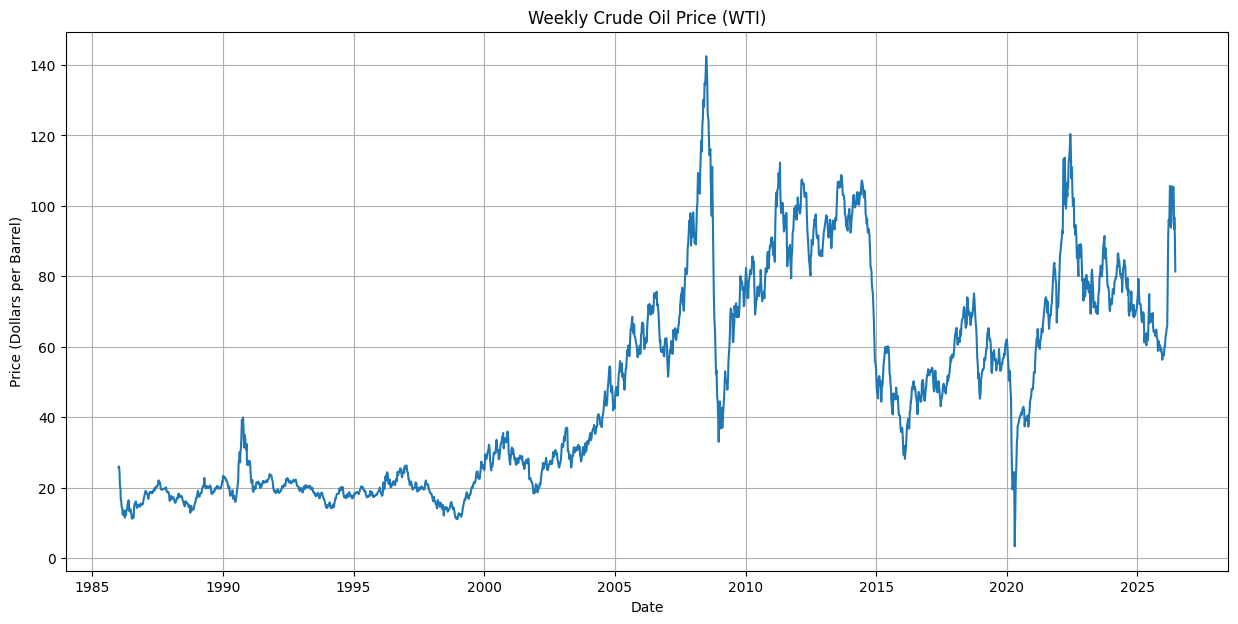

In [50]:
# Convert 'Price' column to numeric, coercing errors to NaN
df_long['Price'] = pd.to_numeric(df_long['Price'], errors='coerce')

# Drop rows where 'Price' is NaN after conversion
df_long.dropna(subset=['Price'], inplace=True)

# Create a 'Base_Date' column by converting 'Year_Month' to the first day of the month
df_long['Base_Date'] = pd.to_datetime(df_long['Year_Month'], format='%Y-%b')

# Extract the week number from the 'Week' column
df_long['Week_Num'] = df_long['Week'].str.extract('(\\d+)').astype(int)

# Create an approximate 'Date' column by adding weeks to the 'Base_Date'
# We subtract 1 from Week_Num because 'Week 1' corresponds to 0 additional weeks from the month start.
df_long['Date'] = df_long['Base_Date'] + pd.to_timedelta((df_long['Week_Num'] - 1) * 7, unit='days')

# Sort the DataFrame by the newly created 'Date' column to ensure correct time series order
df_long.sort_values('Date', inplace=True)

# Plot the time series using seaborn
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_long, x='Date', y='Price')
plt.title('Weekly Crude Oil Price (WTI)')
plt.xlabel('Date')
plt.ylabel('Price (Dollars per Barrel)')
plt.grid(True)
plt.show()


## Heat Map

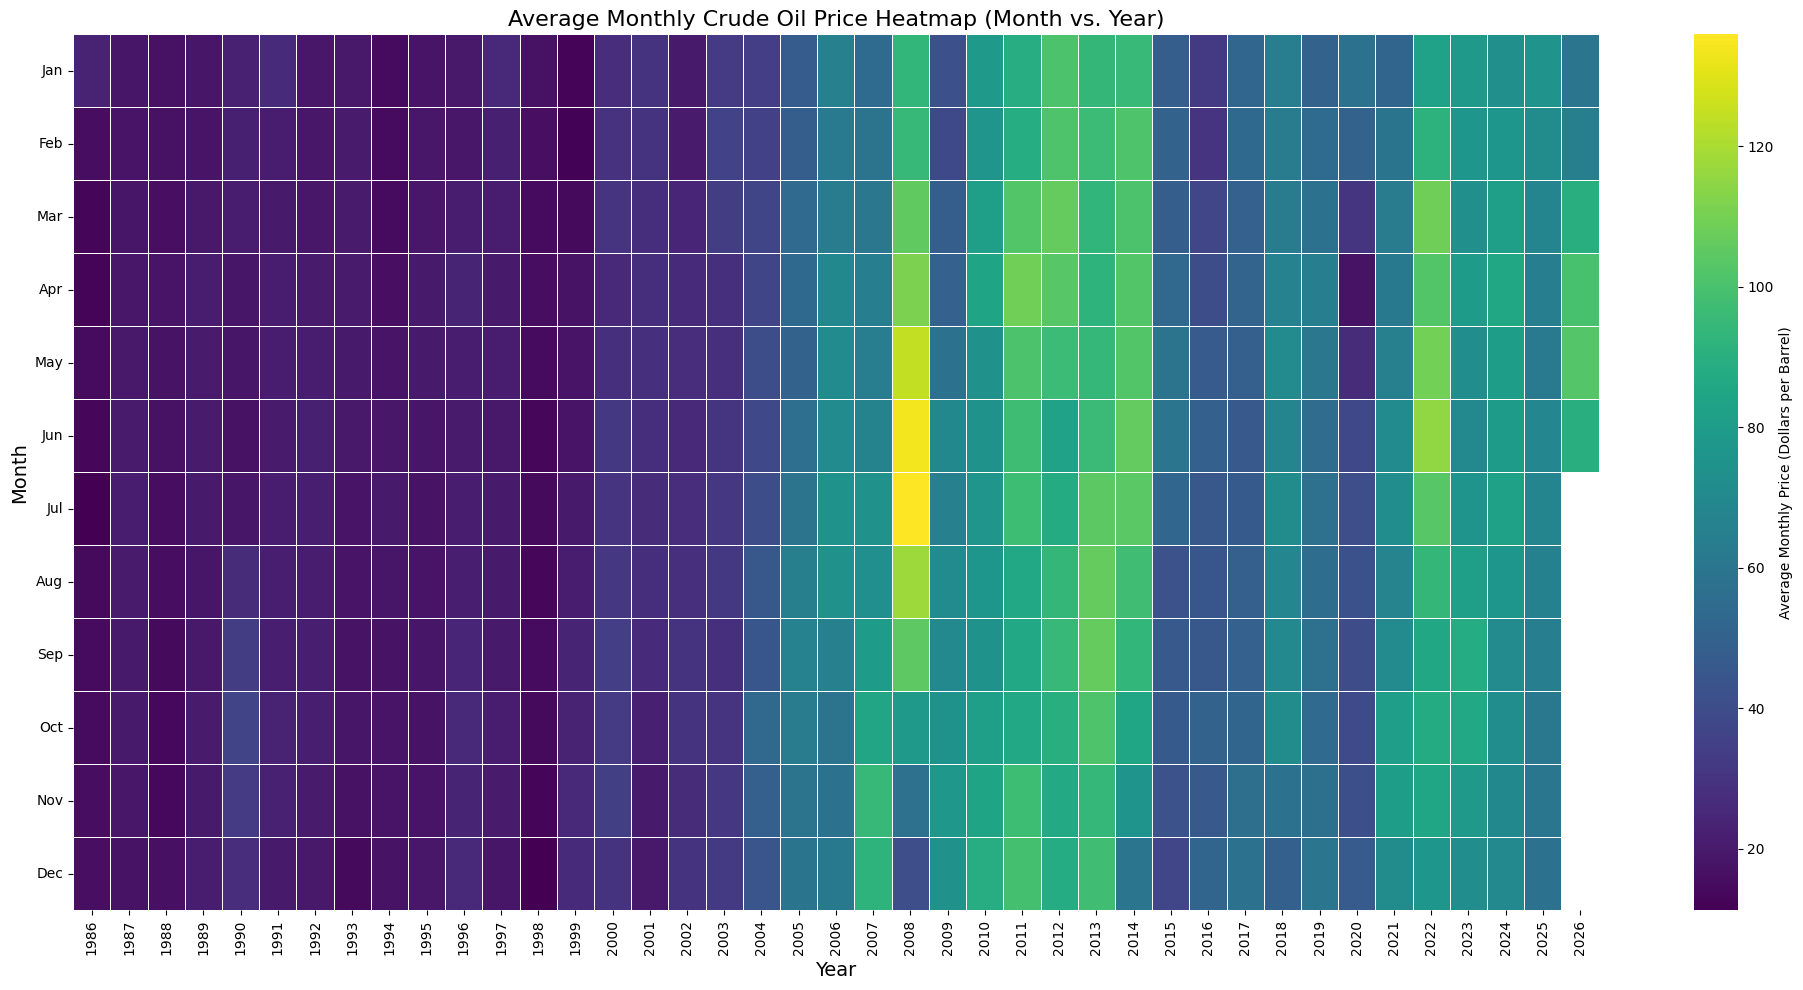

In [51]:
# Extract Year and Month from the Date column
df_long['Year'] = df_long['Date'].dt.year
df_long['Month_Name'] = df_long['Date'].dt.strftime('%b') # Abbreviated month name (Jan, Feb, etc.)
df_long['Month_Num'] = df_long['Date'].dt.month # Numeric month for sorting

# Calculate the average price per month for each year
monthly_avg_price = df_long.groupby(['Year', 'Month_Num', 'Month_Name'])['Price'].mean().reset_index()

# Create a pivot table for the heatmap
# Years will be columns, Months will be index, and values will be the average price
heatmap_data_new = monthly_avg_price.pivot_table(
    index='Month_Name',
    columns='Year',
    values='Price'
)

# Ensure months are in chronological order on the y-axis
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data_new = heatmap_data_new.reindex(month_order)

# Plot the new heatmap
plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
sns.heatmap(
    heatmap_data_new,
    cmap='viridis', # Colormap for visualization
    linewidths=.5, # Adds lines between cells
    cbar_kws={'label': 'Average Monthly Price (Dollars per Barrel)'},
    annot=False # Set to True to show the price values on the heatmap
)
plt.title('Average Monthly Crude Oil Price Heatmap (Month vs. Year)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Month', fontsize=14)
plt.yticks(rotation=0) # Ensure month labels are horizontal
plt.xticks(rotation=90, ha='center') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
